# Characterization of deformable thermal interface materials for power electronics

This notebook processes thermal measurements from several Ni-foam specimens. The reusable logic composed by plot, steady-state finding and so on is in `tim_processing.py`, so, adding a new specimen only requires adding one `SampleConfig` entry below.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from tim_processing import (
    SampleConfig,
    academic_results_table,
    aggregate_results,
    analyze_sample,
    combine_results,
    plot_gauge_measurements,
    plot_temperature,
    plot_thermal_resistance_comparison,
    set_academic_style,
)

set_academic_style(font_size=12)

## Sample configuration

`Sample_ID` is only an integer identifier for each measurement file. \
`Sample` identifies the material with the thickness, for example `Ni foam 1.2 mm`. \
`Specimen` is an integer identifying the physical specimen inside that sample family. \
`area_mm2` is used to convert Force (N) into Pressure (MPa) on the final figure. \
`excluded_temperature_indices` was created to remove defective thermocouples (normally 109 TC7 with index 6) from the thermal-resistance regression.


In [2]:
active_dry_1_2 = True
active_dry_3 = True
active_TG_1_2 = False
active_TG_3 = False

samples = [
    # active = False for samples are not procesed but the data is available in the path.
    # SampleConfig(
    #     sample_id=1,
    #     sample='Copper plate',
    #     specimen=1,
    #     condition='Reference',
    #     file_name='sample_1_18_02_2026.CSV',
    #     label='Copper plate',
    #     area_mm2=144,
    #     skiprows=33,
    #     skip_time_min=90,
    #     active = False,
    # ),
    SampleConfig(
        sample_id=2,
        sample='Ni foam 1.2 mm',
        specimen=1,
        condition='Dry',
        file_name='sample_2_04_03_2026.csv',
        label='Ni foam 1.2 mm - specimen 1',
        area_mm2=144,
        skiprows=8,
        skip_time_min=50,
        active = active_dry_1_2,
    ),
    SampleConfig(
        sample_id=3,
        sample='Ni foam 1.2 mm',
        specimen=1,
        condition='Silicone-based thermal grease',
        file_name='sample_3_11_03_2026.csv',
        label='Ni foam 1.2 mm + silicone grease - specimen 1',
        area_mm2=100,
        skiprows=8,
        skip_time_min=20,
        active = False
    ),
     SampleConfig(
        sample_id=4,
        sample='Ni foam 1.2 mm',
        specimen=1,
        condition='Silver-based thermal grease',
        file_name='sample_4_19_03_2026.csv',
        label='Ni foam 1.2 mm + silver grease - specimen 1',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
         active = active_TG_1_2
    ),
    SampleConfig(
        sample_id=5,
        sample='Ni foam 3.0 mm',
        specimen=1,
        condition='Dry',
        file_name='sample_5_01_04_2026.csv',
        label='Ni foam 3.0 mm - specimen 1',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        active = active_dry_3
    ),
    SampleConfig(
        sample_id=6,
        sample='Ni foam 1.2 mm',
        specimen=2,
        condition='Dry',
        file_name='sample_6_22_04_2026.csv',
        label='Ni foam 1.2 mm - specimen 2',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        active = active_dry_1_2
    ),
    SampleConfig(
        sample_id=7,
        sample='Ni foam 3.0 mm',
        specimen=2,
        condition='Dry',
        file_name='sample_7_29_04_2026.csv',
        label='Ni foam 3.0 mm - specimen 2',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        # TC7 is very noisy in this measurement
        excluded_temperature_indices=(6,),
        active = active_dry_3
    ),
     SampleConfig(
        sample_id=8,
        sample='Ni foam 1.2 mm',
        specimen=2,
        condition='Silver-based thermal grease',
        file_name='sample_8_13_05_2026.csv',
        label='Ni foam 1.2 mm + silver grease  - specimen 2',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        # TC7 is very noisy in this measurement
        excluded_temperature_indices=(6,),
         active = active_TG_1_2
    ),
    SampleConfig(
        sample_id=9,
        sample='Ni foam 3.0 mm',
        specimen=1,
        condition='Silver-based thermal grease',
        file_name='sample_9_19_05_2026.csv',
        label='Ni foam 3.0 mm + silver grease - specimen 1',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        active = active_TG_3
    ),
    SampleConfig(
        sample_id=10,
        sample='Ni foam 3.0 mm',
        specimen=2,
        condition='Silver-based thermal grease',
        file_name='sample_10_19_05_2026.csv',
        label='Ni foam 3.0 mm + silver grease - specimen 2',
        area_mm2=144,
        skiprows=8,
        skip_time_min=20,
        active = active_TG_3
    )
]

active_samples = [sample for sample in samples if sample.active]


## Processing

This section loads each active sample, detects steady-state regions, calculates thermal resistance for each force step (from 200N to 1000N), and stores all results in a table. The academic table can show individual measurements, mean rows, or both.


2: filtering noise and searching steady states
  10:54:21: accepted (max variation 0.073 deg C)
  11:49:44: accepted (max variation 0.099 deg C)
  12:50:16: accepted (max variation 0.074 deg C)
  13:49:20: accepted (max variation 0.074 deg C)
  14:49:31: accepted (max variation 0.106 deg C)
5: filtering noise and searching steady states
  09:10:43: rejected (max variation 48.363 deg C)
  09:25:43: rejected (max variation 4.366 deg C)
  10:12:29: accepted (max variation 0.279 deg C)
  10:27:29: rejected (max variation 1.024 deg C)
  11:13:17: accepted (max variation 0.188 deg C)
  11:28:17: rejected (max variation 0.893 deg C)
  12:13:00: accepted (max variation 0.135 deg C)
  13:11:00: accepted (max variation 0.124 deg C)
  14:32:27: accepted (max variation 0.162 deg C)
6: filtering noise and searching steady states
  10:19:06: accepted (max variation 0.237 deg C)
  10:34:06: rejected (max variation 0.825 deg C)
  12:31:39: accepted (max variation 0.177 deg C)
  13:33:59: accepted (max

/home/silvapeb/notebooks/M1/Research Project/tim_processing.py:516: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6.0, 4.2))


,Result_Type,Sample_ID,Sample,Specimen,Condition,Period,Excluded_temperature_indices,Hot_temperature_indices_used,Cold_temperature_indices_used,n,...,Force_N_std,Pressure_MPa,Pressure_MPa_std,Q_average_W,Delta_T_C,Thermal_resistance_K_W,Specific_thermal_resistance_K_cm2_W,Specific_thermal_resistance_std,Hot_fit_R2,Cold_fit_R2
5,Measurement,6,Ni foam 1.2 mm,2,Dry,1,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,1.4962,<NA>,14.718785,55.79484,3.790723,5.4586,<NA>,0.991931,0.999253
6,Measurement,6,Ni foam 1.2 mm,2,Dry,2,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,2.1171,<NA>,16.058038,34.342132,2.138626,3.0796,<NA>,0.998335,0.999638
0,Measurement,2,Ni foam 1.2 mm,1,Dry,1,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,2.1503,<NA>,13.957923,28.813059,2.06428,2.9726,<NA>,0.998114,0.99881
1,Measurement,2,Ni foam 1.2 mm,1,Dry,2,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,2.7656,<NA>,14.096282,26.688777,1.89332,2.7264,<NA>,0.999732,0.999144
7,Measurement,6,Ni foam 1.2 mm,2,Dry,3,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,3.5343,<NA>,16.700923,22.023613,1.318706,1.8989,<NA>,0.999309,0.999398
2,Measurement,2,Ni foam 1.2 mm,1,Dry,3,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,3.9273,<NA>,14.323948,20.519296,1.432517,2.0628,<NA>,0.999717,0.99904
8,Measurement,6,Ni foam 1.2 mm,2,Dry,4,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,5.3763,<NA>,16.995136,15.259537,0.897877,1.2929,<NA>,0.998352,0.998953
3,Measurement,2,Ni foam 1.2 mm,1,Dry,4,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,5.3865,<NA>,14.771421,14.620972,0.989815,1.4253,<NA>,0.999874,0.998907
4,Measurement,2,Ni foam 1.2 mm,1,Dry,5,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,6.7464,<NA>,14.67032,12.440566,0.848009,1.2211,<NA>,0.999155,0.998932
9,Measurement,6,Ni foam 1.2 mm,2,Dry,5,(),"(0, 1, 2, 3)","(4, 5, 6, 7)",<NA>,...,<NA>,7.2991,<NA>,17.146682,11.688192,0.681659,0.9816,<NA>,0.998221,0.998969


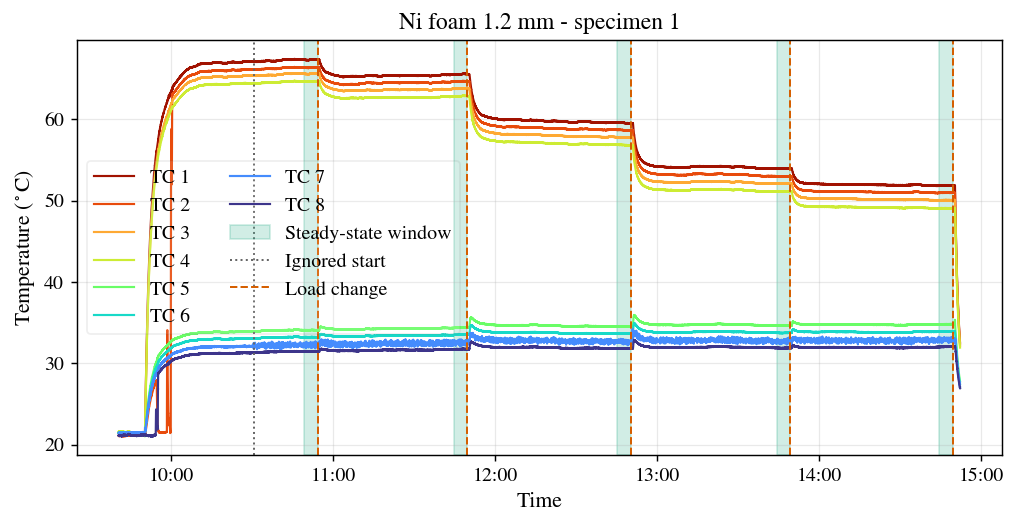

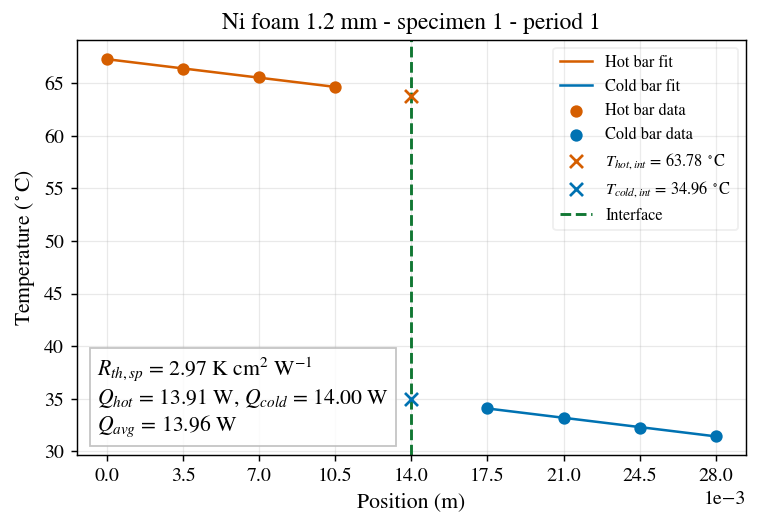

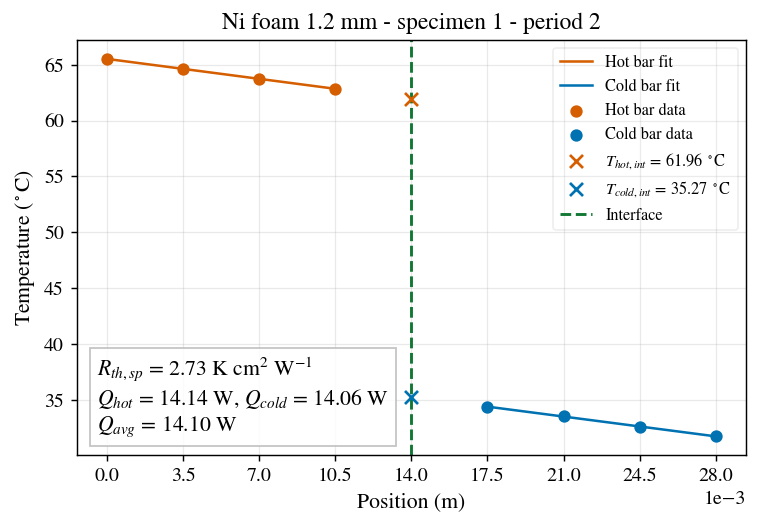

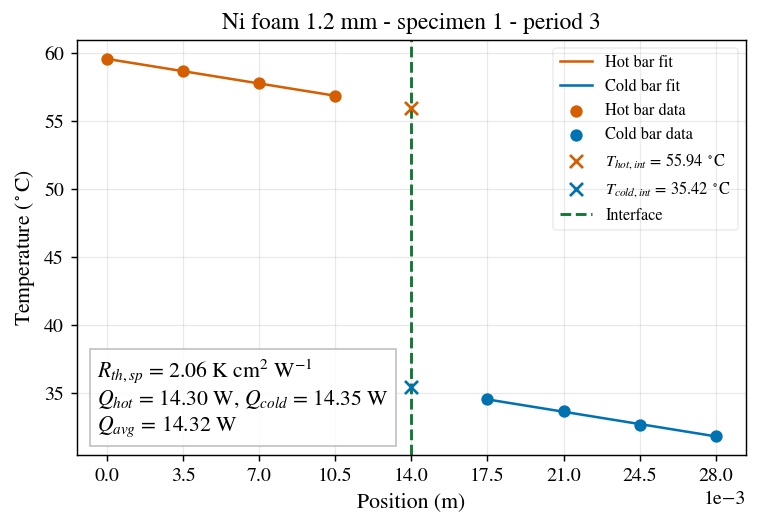

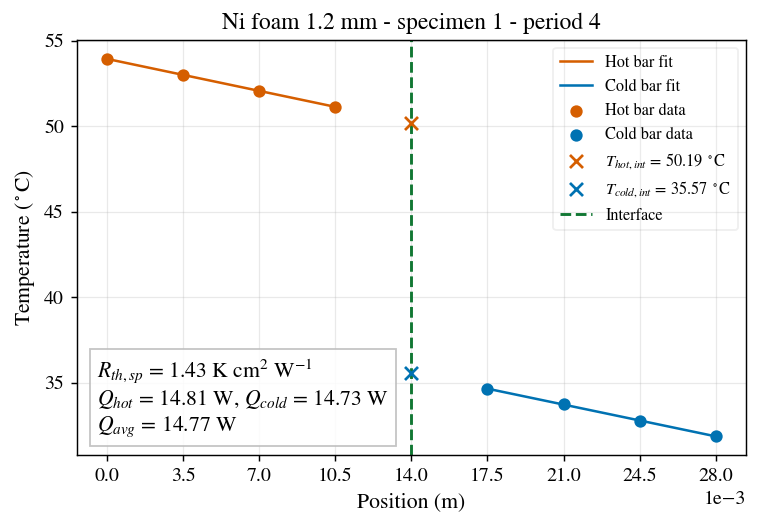

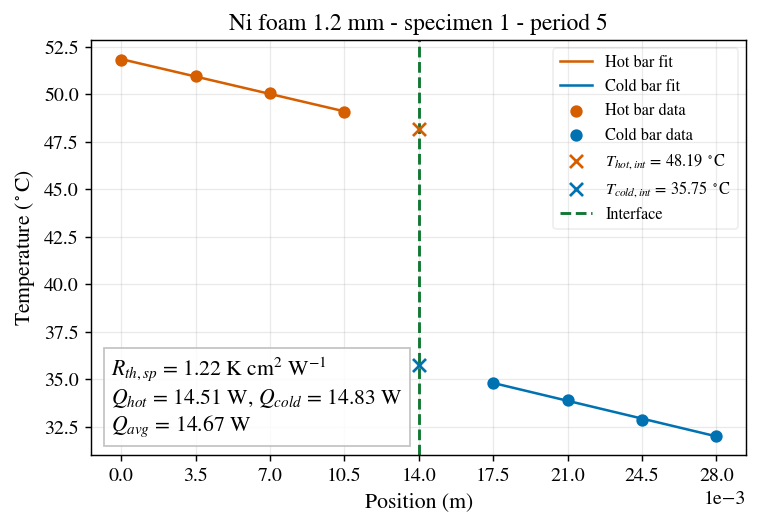

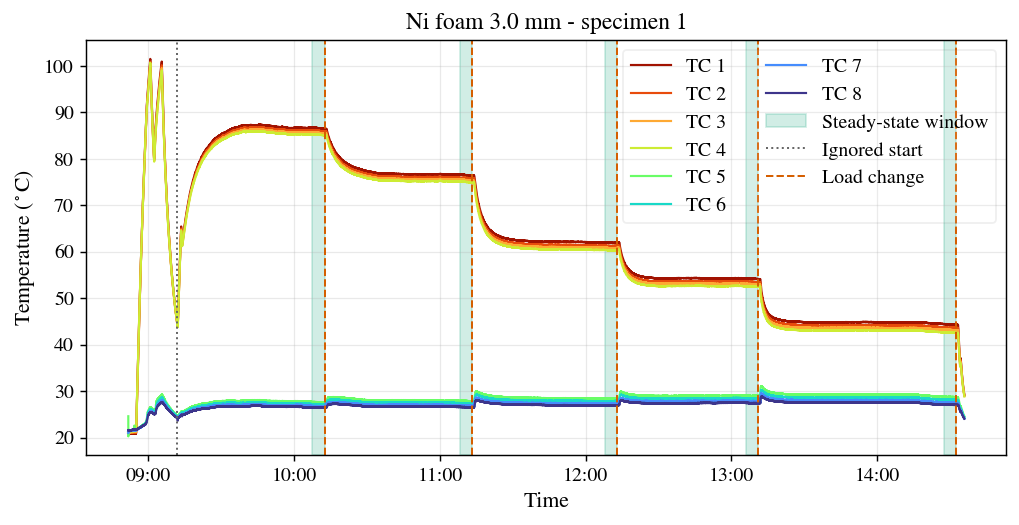

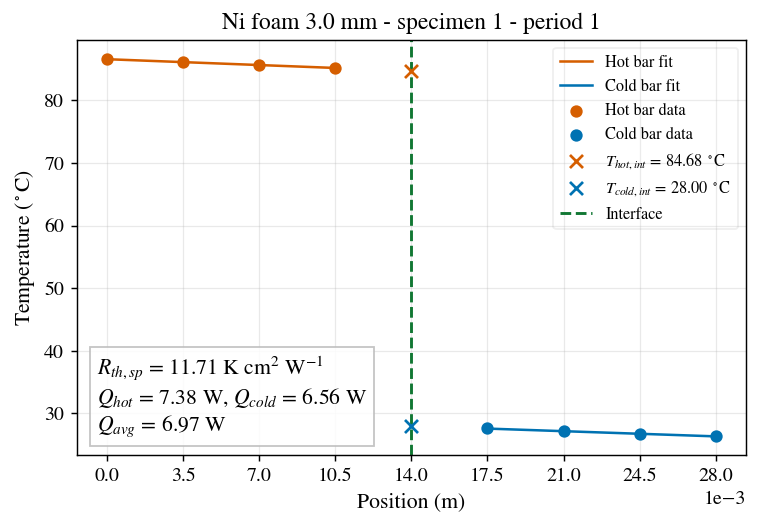

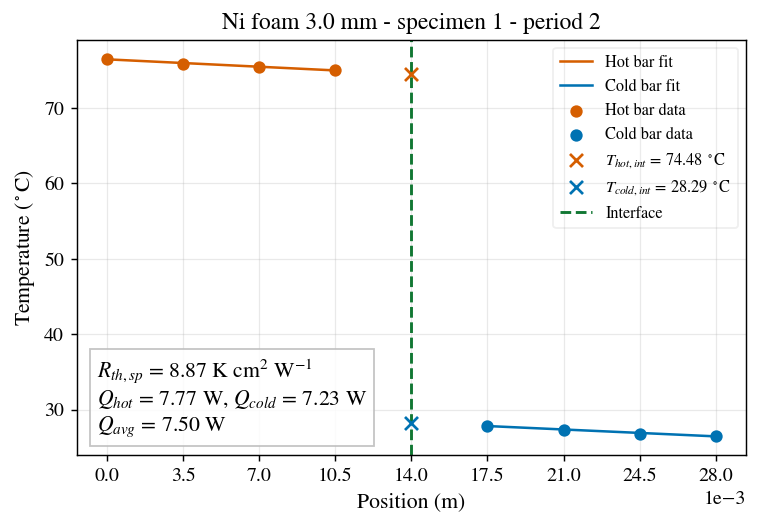

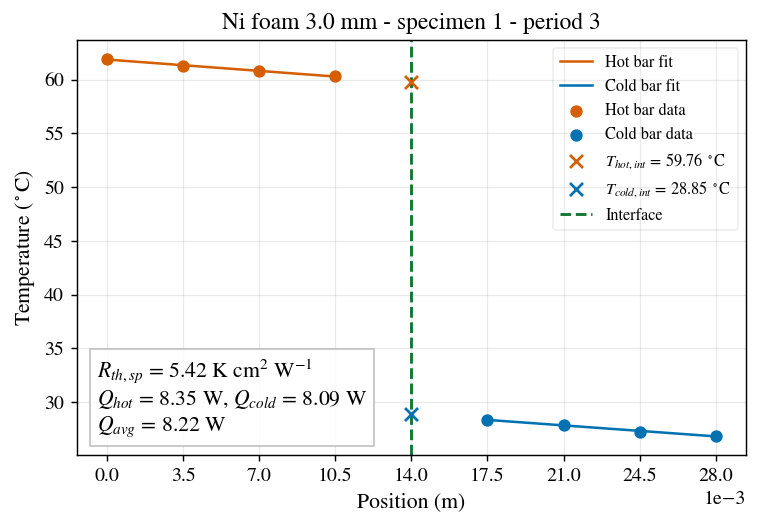

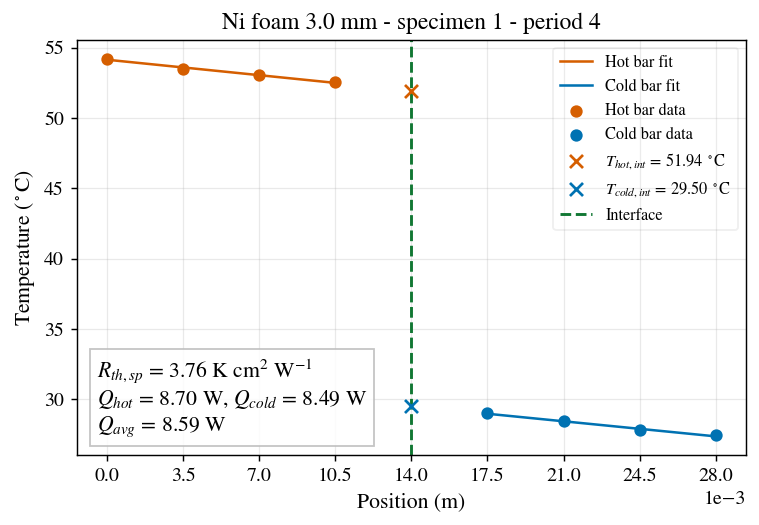

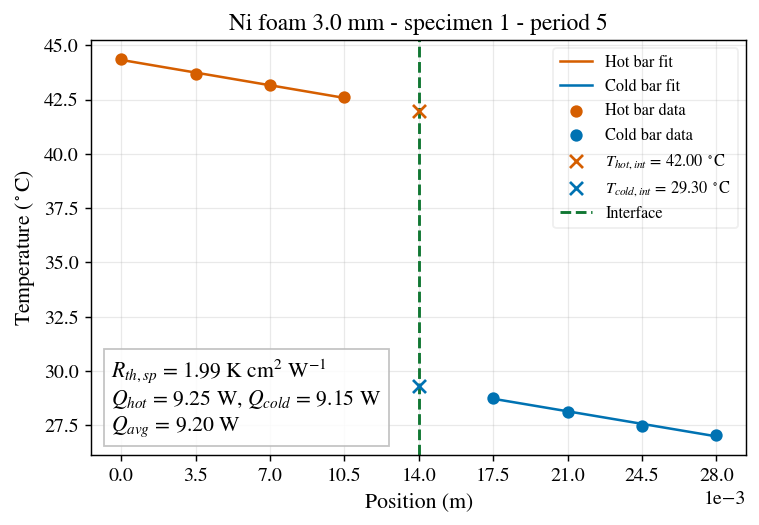

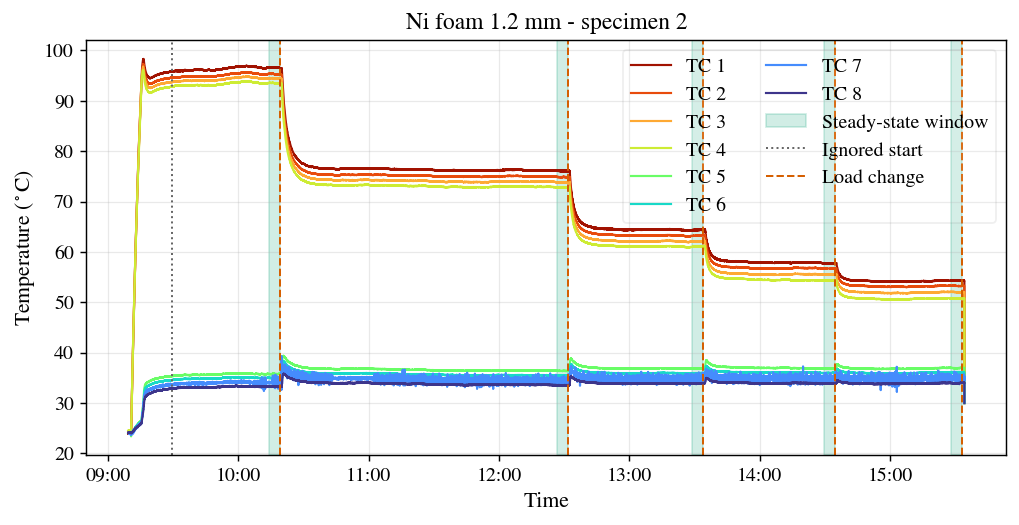

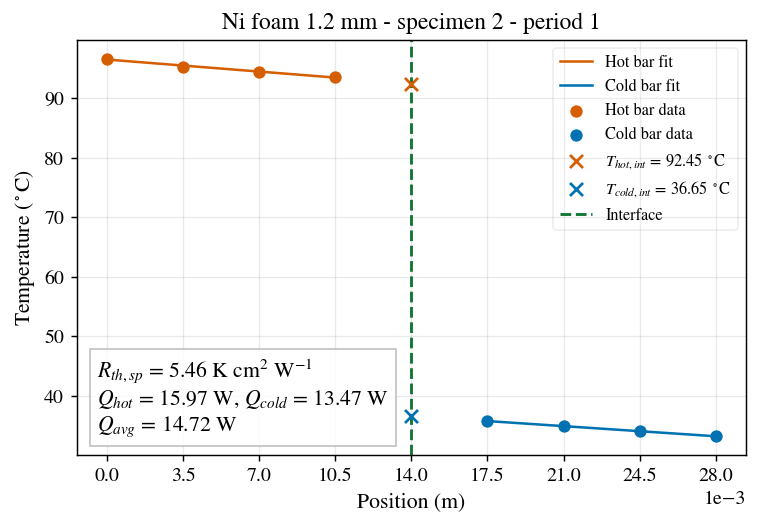

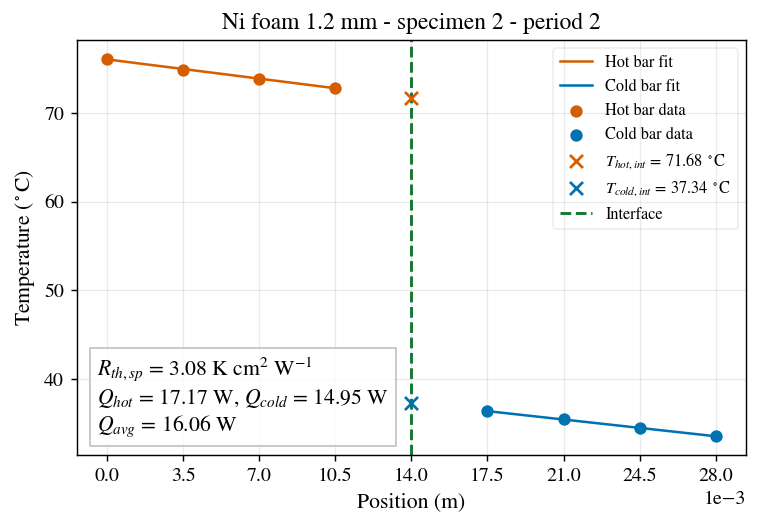

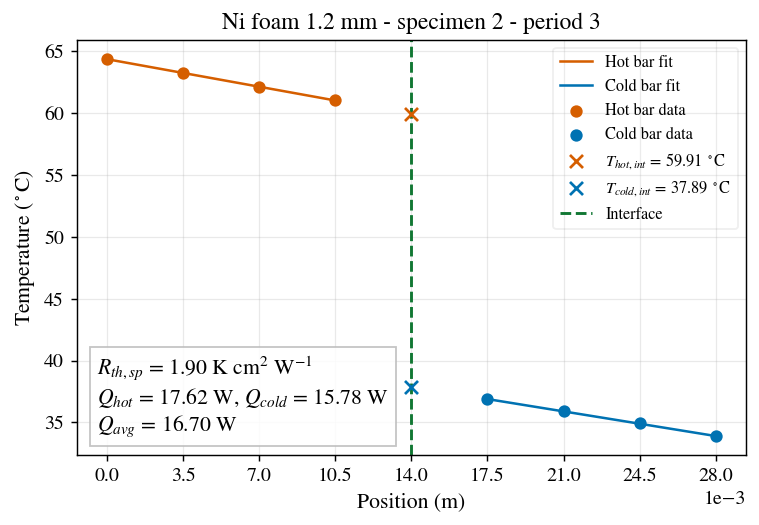

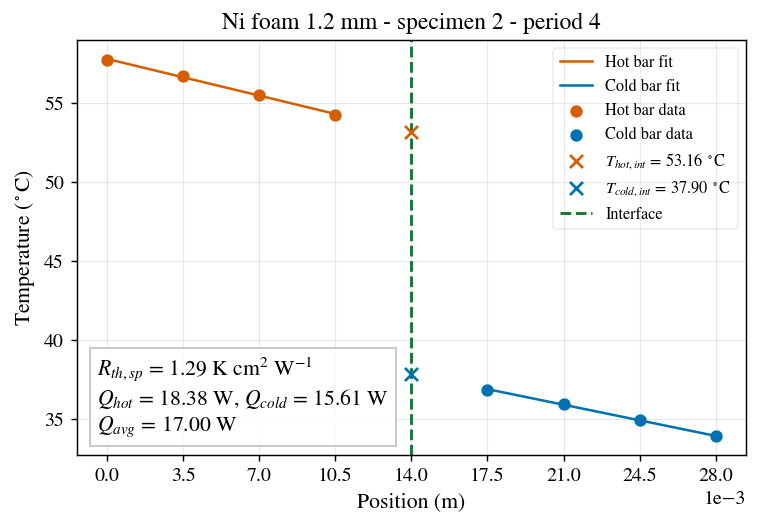

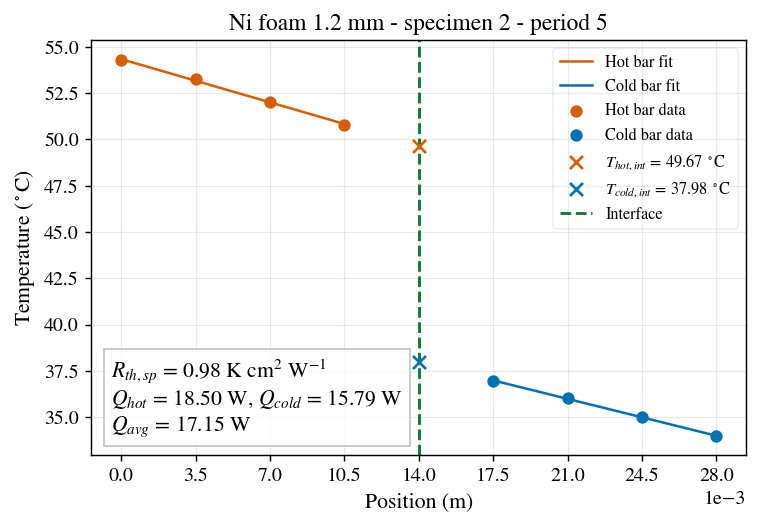

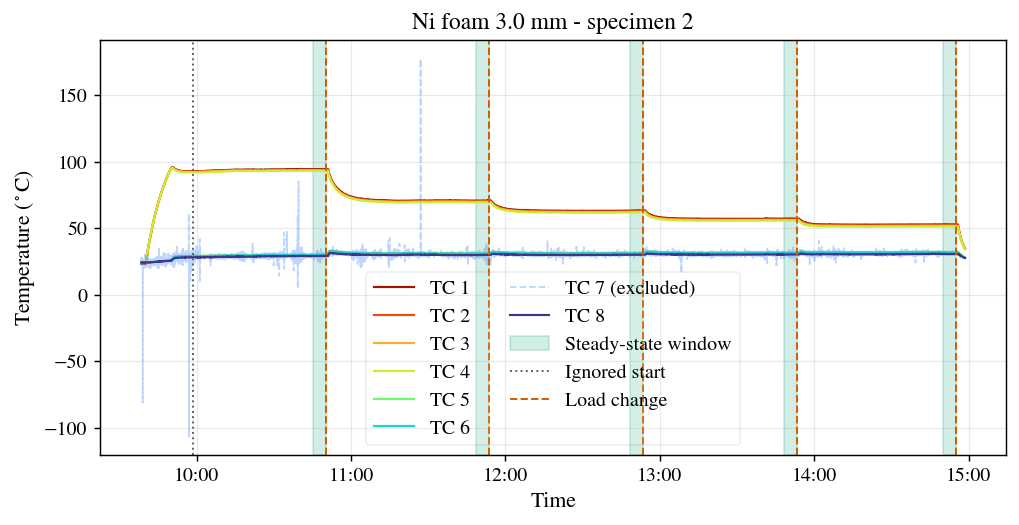

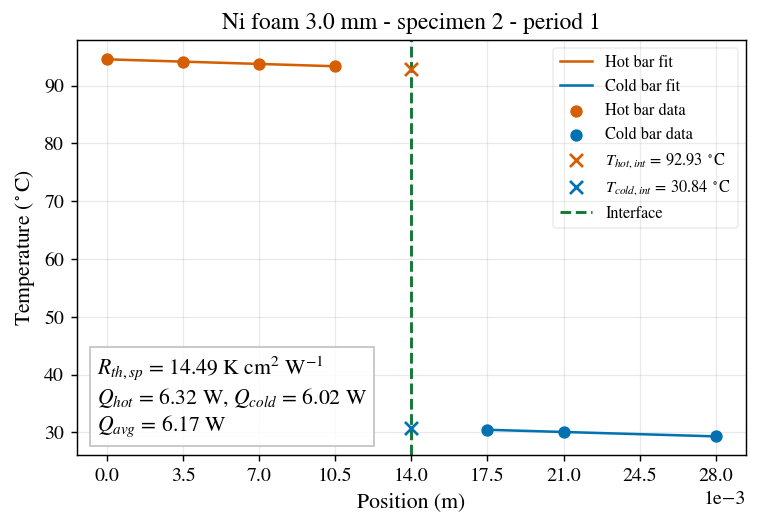

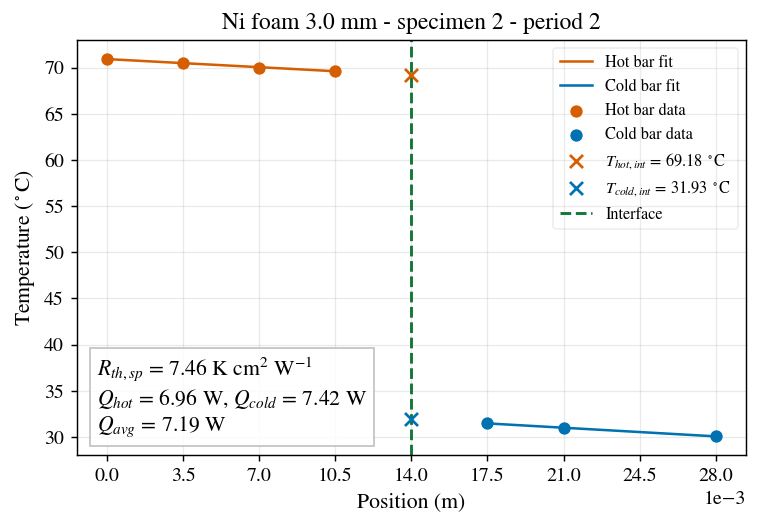

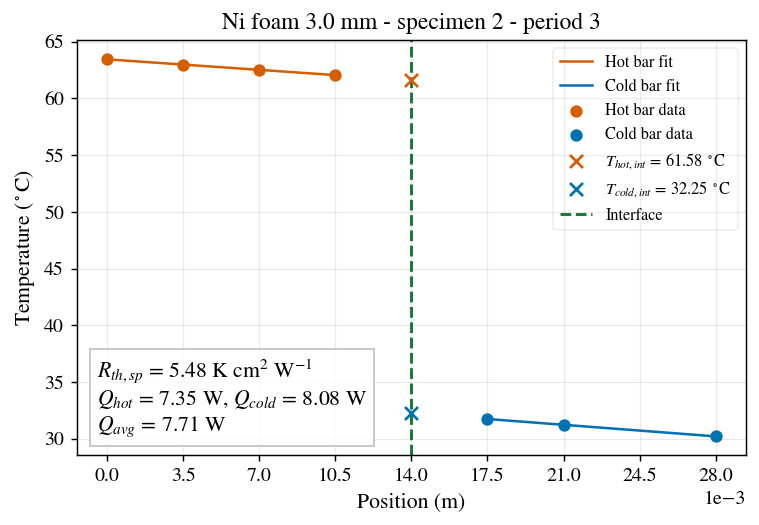

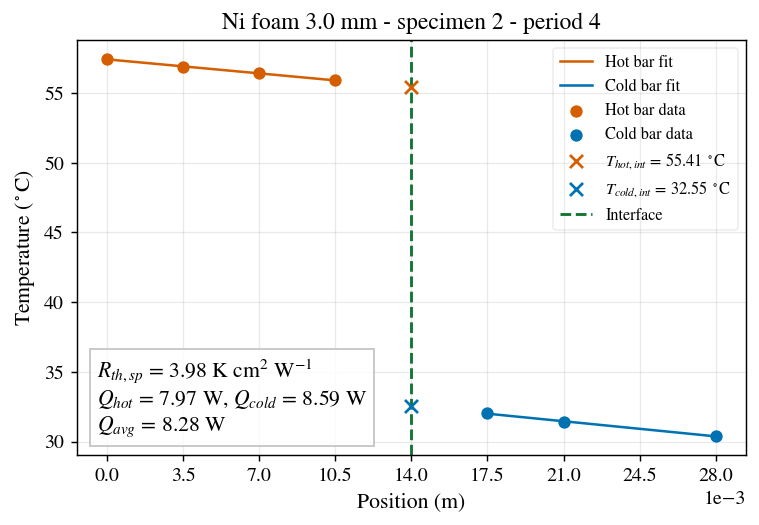

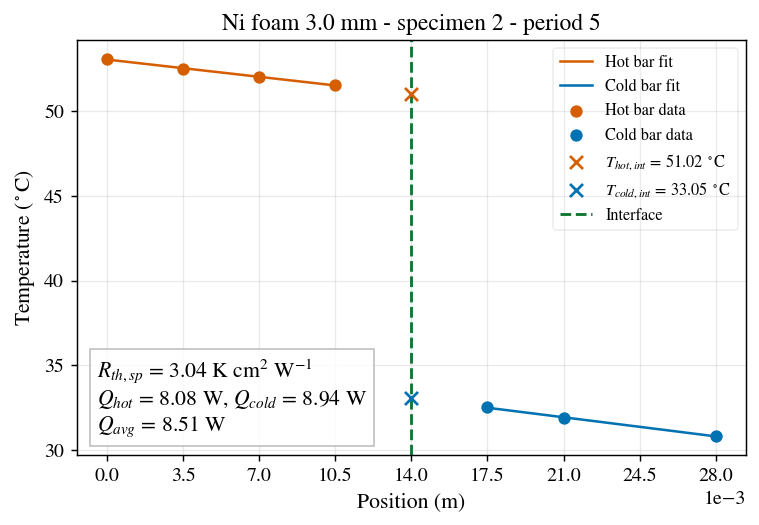

In [3]:
loaded_samples = {}
steady_states = {}
result_tables = {}

for config in active_samples:
    loaded, steady_state, results = analyze_sample(
        config,
        base_dir='.',
        plot_steady_state=True,
        plot_regressions=True,
        verbose=True,
    )
    loaded_samples[config.sample_id] = loaded
    steady_states[config.sample_id] = steady_state
    result_tables[config.sample_id] = results

results = combine_results(result_tables.values())
academic_results_table(
    results,
    include_measurements=True,
    include_mean=True,
    mean_group_by=('Sample', 'Condition'),
    force_bin_width_n=200,
)


## Grouped averages

Present average repeated specimens by force or pressure. This makes it possible to compare same samples even when the exact applied force is slightly different between tests.


Adding results from Paul's thesis for Ni-foam 3mm thickness

In [4]:
if active_dry_3:
    Q_hot_1 = [9.4579760000002, 10.6615995200003, 11.1663024000001, 11.3827049600003, 11.4354574400001]
    Q_hot_2 = [8.40716448000031, 9.25807872000038, 9.71585824000026, 10.1412502400004, 10.3196614400002]
    Q_cold_1 = [8.69816463999997, 9.87181007999997, 10.3972264, 10.69674144, 10.81655696]
    Q_cold_2 = [7.03668239999996, 8.02030063999996, 8.64426111999999, 9.1927686399999, 9.43027711999996]
    Q_average_1 = [9.07807032000008, 10.2667048000001, 10.7817644, 11.0397232000001, 11.1260072000001]
    Q_average_2 = [7.72192344000014, 8.63918968000017, 9.18005968000012, 9.66700944000013, 9.8749692800001]
    Delta_T_1 = [64.2881094444444, 39.0420622222222, 28.4044516666666, 22.5387072222222, 19.7445466666667]
    Delta_T_2 = [73.541095, 53.6063483333333, 39.3660333333333, 27.6057066666666, 22.7408788888889]
    
    Rth_1 = [7.08169326501139, 3.80278414377139, 2.63449010874941, 2.04160075519121, 1.77463004577838]
    Rth_2 = [9.52367574884926, 6.20502041498552, 4.28821104715659, 2.85566149883332, 2.30288097553339]
    
    Rth_sp_1 = [10.1976383016164, 5.4760091670308, 3.79366575659915, 2.93990508747534, 2.55546726592086]
    Rth_sp_2 = [13.7140930783429, 8.93522939757915, 6.17502390790549, 4.11215255831999, 3.31614860476808]
    
    Force = [200, 400, 600, 800, 1000]
    
    for i in range(len(Force)):
        ni_3_3 = {
            "Sample_ID": 20,
            "Sample": 'Ni foam 3.0 mm',	        
            "Specimen": 3,
            "Condition": 'Dry',
            "Label": 'Ni foam 3.0 mm - specimen 3',
            "Period": i+1,
            "Area_mm2": 144,
            "Excluded_temperature_indices": 0,
            "Hot_temperature_indices_used": (0,1,2,3),
            "Cold_temperature_indices_used": (4,5,6,7),
            "Q_hot_W": Q_hot_1[i],
            "Q_cold_W": Q_cold_1[i],
            "Q_average_W": Q_average_1[i],
            "Thermal_resistance_K_W": Rth_1[i],
            "Specific_thermal_resistance_K_cm2_W": Rth_sp_1[i],
            "Hot_fit_R2": 1,
            "Cold_fit_R2": 1,
            "Force": Force[i],
            "Force_N": Force[i],
            "R_th": Rth_1[i],
            "R_th_sp": Rth_sp_1[i],
            "Delta_T_C": Delta_T_1,
        }
        ni_3_4 = {
            "Sample_ID": 21,
            "Sample": 'Ni foam 3.0 mm',	        
            "Specimen": 4,
            "Condition": 'Dry',
            "Label": 'Ni foam 3.0 mm - specimen 4',
            "Period": i+1,
            "Area_mm2": 144,
            "Excluded_temperature_indices": 0,
            "Hot_temperature_indices_used": (0,1,2,3),
            "Cold_temperature_indices_used": (4,5,6,7),
            "Q_hot_W": Q_hot_2[i],
            "Q_cold_W": Q_cold_2[i],
            "Q_average_W": Q_average_2[i],
            "Thermal_resistance_K_W": Rth_2[i],
            "Specific_thermal_resistance_K_cm2_W": Rth_sp_2[i],
            "Hot_fit_R2": 1,
            "Cold_fit_R2": 1,
            "Force": Force[i],
            "Force_N": Force[i],
            "R_th": Rth_2[i],
            "R_th_sp": Rth_sp_2[i],
            "Delta_T_C": Delta_T_2,
        }
        ni_3_3_pd = pd.DataFrame([ni_3_3])
        ni_3_4_pd = pd.DataFrame([ni_3_4])
        results = pd.concat([results,ni_3_3_pd,ni_3_4_pd])

In [5]:
averaged_results = aggregate_results(
    results,
    group_by=('Sample', 'Condition'),
    force_bin_width_n=200,
    y_column='Specific_thermal_resistance_K_cm2_W',
)

averaged_results.round(4)


,Sample,Condition,Force_bin_N,n,Force_N,Force_N_std,Pressure_MPa,Pressure_MPa_std,Thermal_resistance_mean,Thermal_resistance_std,Thermal_resistance_sem,Area_mm2
0,Ni foam 1.2 mm,Dry,200.0,1,215.4598,NaN,1.4962,NaN,5.4586,NaN,NaN,144.0
1,Ni foam 1.2 mm,Dry,400.0,3,337.5815,52.5884,2.3443,0.3652,2.9262,0.1811,0.1046,144.0
2,Ni foam 1.2 mm,Dry,600.0,2,537.2365,40.0211,3.7308,0.2779,1.9809,0.1159,0.0819,144.0
3,Ni foam 1.2 mm,Dry,800.0,2,774.9211,1.0323,5.3814,0.0072,1.3591,0.0936,0.0662,144.0
4,Ni foam 1.2 mm,Dry,1000.0,2,1011.2784,56.2803,7.0228,0.3908,1.1014,0.1694,0.1198,144.0
5,Ni foam 3.0 mm,Dry,200.0,4,209.8000,14.3765,1.5250,0.1067,12.5273,1.9463,0.9731,144.0
6,Ni foam 3.0 mm,Dry,400.0,4,370.5751,35.7256,2.3691,0.1328,7.6855,1.6225,0.8112,144.0
7,Ni foam 3.0 mm,Dry,600.0,4,563.7995,44.1928,3.6639,0.1725,5.2152,1.0084,0.5042,144.0
8,Ni foam 3.0 mm,Dry,800.0,4,767.9882,37.7040,5.1109,0.0894,3.6970,0.5251,0.2626,144.0
9,Ni foam 3.0 mm,Dry,1000.0,4,1001.0534,55.9147,6.9591,0.6724,2.7252,0.5831,0.2916,144.0


## Final comparison figure

The bottom x-axis is Force (N), the y-axis is the specific thermal resistance, and the top x-axis is Pressure (MPa), and solid mean curves summarise each specimen.


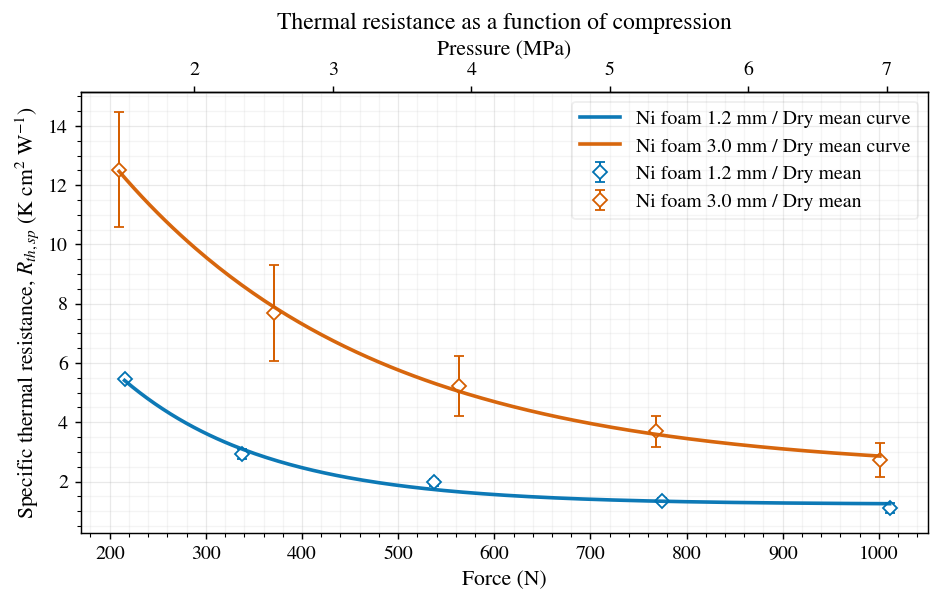

In [6]:
fig, ax = plot_thermal_resistance_comparison(
    results,
    group_by='Label',
    y_column='Specific_thermal_resistance_K_cm2_W',
    fit=False,
    show_average=True,
    average_by=('Sample', 'Condition'),
    force_bin_width_n=200,
    mean_curve=True,
    specimen_curve_points=True, # True if want to hide specimen curve points
    pressure_area_mm2=144,
)
plt.show()


ValueError: No results available to plot.

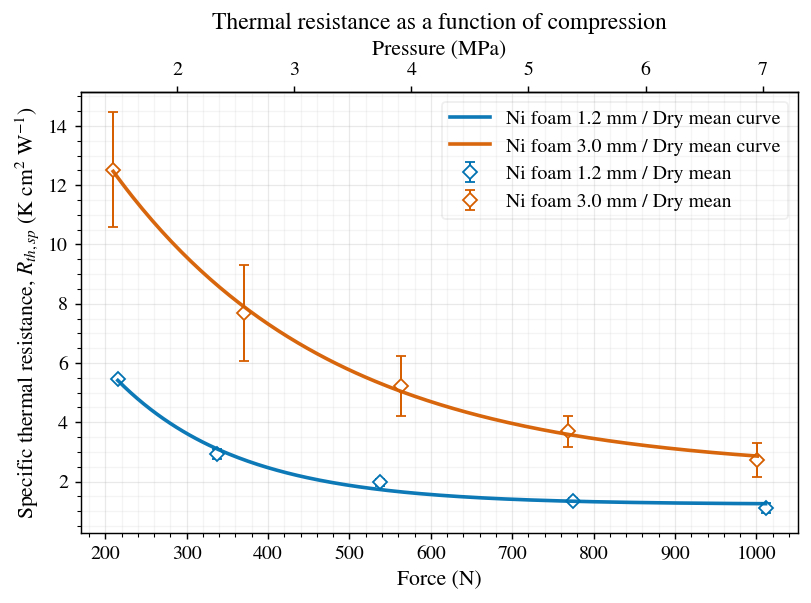

In [7]:
fig, ax = plt.subplots()

# ---- Condición 1 -> SOLO mean curve ----
plot_thermal_resistance_comparison(
    results[results['Condition'] == 'Dry'],
    group_by='Condition',
    y_column='Specific_thermal_resistance_K_cm2_W',
    fit=True,
    show_average=True,
    average_by=('Sample','Condition'),
    force_bin_width_n=200,
    mean_curve=True,
    specimen_curve_points=True,
    pressure_area_mm2=144,
    ax=ax
)

# ---- Condición 2 -> SOLO puntos mean ----
plot_thermal_resistance_comparison(
    results[results['Condition'] == 'Silver-based thermal grease'],
    group_by='Condition',
    y_column='Specific_thermal_resistance_K_cm2_W',
    fit=False,
    show_average=True,
    average_by=('Sample','Condition'),
    force_bin_width_n=200,
    mean_curve=False,
    specimen_curve_points=True,
    pressure_area_mm2=144,
    ax=ax,
    custom_color='#D55E00'
)

plt.show()